# Horizonte 5 dias + Feature Engineering de Sentimento

Duas mudanças em relação à Etapa 4:
1. **Horizonte reduzido:** 21 → 5 dias úteis (sentimento tem impacto de curto prazo)
2. **Features temporais de sentimento:** médias móveis, variação, razão pos/neg

Objetivo: verificar se o sinal de sentimento FinBERT é mais preditivo no curto prazo
e se features derivadas melhoram a discriminação dos modelos.

## 1. Construção do Dataset com Features Temporais de Sentimento

In [1]:
import sys
sys.path.insert(0, '../3.model_traning')

import pandas as pd
import numpy as np

# Load price features
X_full = pd.read_csv('../2.stocks/dataset_full.csv', index_col=0, parse_dates=True)
X_full.index = pd.to_datetime(X_full.index, utc=True).tz_localize(None)
price_cols = [c for c in X_full.columns if not c.startswith('emb_')]
X_prices = X_full[price_cols].copy()

# Load and merge FinBERT sentiment
sentiment = pd.read_csv('../4.finbert-br/itub4_daily_sentiment.csv', index_col=0, parse_dates=True)
X_combined = X_prices.join(sentiment, how='left')
sent_cols = sentiment.columns.tolist()
X_combined[sent_cols] = X_combined[sent_cols].ffill()

# === Feature Engineering de Sentimento ===

# Médias móveis de sentimento (7 e 21 dias)
for col in ['mean_logit_pos', 'mean_logit_neg', 'mean_logit_neu', 'mean_sentiment']:
    X_combined[f'{col}_ma7'] = X_combined[col].rolling(7).mean()
    X_combined[f'{col}_ma21'] = X_combined[col].rolling(21).mean()

# Delta de sentimento (hoje vs média de 7 dias)
for col in ['mean_logit_pos', 'mean_logit_neg', 'mean_sentiment']:
    X_combined[f'{col}_delta7'] = X_combined[col] - X_combined[f'{col}_ma7']

# Razão positivo/negativo (evitar divisão por zero)
X_combined['pos_neg_ratio'] = X_combined['mean_logit_pos'] / (X_combined['mean_logit_neg'].abs() + 1e-6)
X_combined['pos_neg_ratio_ma7'] = X_combined['pos_neg_ratio'].rolling(7).mean()

# Volume de notícias acumulado (7 e 21 dias)
X_combined['n_articles_sum7'] = X_combined['n_articles'].rolling(7).sum()
X_combined['n_articles_sum21'] = X_combined['n_articles'].rolling(21).sum()

# Volatilidade do sentimento (std 7 dias)
X_combined['sentiment_std7'] = X_combined['mean_sentiment'].rolling(7).std()

# Drop NaN from rolling
X_combined = X_combined.dropna()

new_features = [c for c in X_combined.columns if c not in X_prices.columns and c not in sent_cols]
print(f'Features originais (preço): {len(price_cols)}')
print(f'Features sentimento base: {len(sent_cols)}')
print(f'Features sentimento derivadas: {len(new_features)}')
print(f'Total features: {len(X_combined.columns)}')
print(f'Dataset: {X_combined.shape}')
print(f'\nNovas features: {new_features}')

Features originais (preço): 11
Features sentimento base: 5
Features sentimento derivadas: 16
Total features: 32
Dataset: (1207, 32)

Novas features: ['mean_logit_pos_ma7', 'mean_logit_pos_ma21', 'mean_logit_neg_ma7', 'mean_logit_neg_ma21', 'mean_logit_neu_ma7', 'mean_logit_neu_ma21', 'mean_sentiment_ma7', 'mean_sentiment_ma21', 'mean_logit_pos_delta7', 'mean_logit_neg_delta7', 'mean_sentiment_delta7', 'pos_neg_ratio', 'pos_neg_ratio_ma7', 'n_articles_sum7', 'n_articles_sum21', 'sentiment_std7']


## 2. Preparação — Horizonte de 5 dias

Target: 1 = Close[t+5] > Close[t] (sobe em 5 dias úteis)

In [2]:
from lstm_classifier import build_dataset

HORIZON = 5

X_seq, y, dates, features, scaler = build_dataset(
    X_combined,
    horizon=HORIZON,
    pca_components=32,
    window=30,
)

print(f'Sequences: {X_seq.shape}')
print(f'Balance: {y.mean():.1%} sobe / {1-y.mean():.1%} desce')
print(f'Features ({len(features)}): {features}')

10:09:11 [INFO] Shape de entrada: (1207, 32)
10:09:11 [INFO] Distribuição do target: {1: 643, 0: 559}  (balance: 53.5% sobe)
10:09:11 [INFO] Features finais: 32
10:09:11 [INFO] Sequências geradas: (1172, 30, 32)  →  y: (1172,)


Sequences: (1172, 30, 32)
Balance: 54.0% sobe / 46.0% desce
Features (32): ['Close', 'Volume', 'return', 'ma7', 'ma21', 'std21', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'n_articles', 'mean_logit_pos', 'mean_logit_neg', 'mean_logit_neu', 'mean_sentiment', 'mean_logit_pos_ma7', 'mean_logit_pos_ma21', 'mean_logit_neg_ma7', 'mean_logit_neg_ma21', 'mean_logit_neu_ma7', 'mean_logit_neu_ma21', 'mean_sentiment_ma7', 'mean_sentiment_ma21', 'mean_logit_pos_delta7', 'mean_logit_neg_delta7', 'mean_sentiment_delta7', 'pos_neg_ratio', 'pos_neg_ratio_ma7', 'n_articles_sum7', 'n_articles_sum21', 'sentiment_std7']


## 3. Treinamento dos 4 Modelos

In [3]:
from lstm_classifier import train, evaluate
from xgboost_baseline import build_flat_dataset, train_xgboost, evaluate_xgboost
from transformer_classifier import train_transformer, evaluate_transformer

print('=== BiLSTM Original (2L/128h) ===')
model_orig, hist_orig, test_idx_orig, device = train(
    X_seq, y, dates, hidden_size=128, n_layers=2, dropout=0.3, epochs=50, patience=10)
probs_orig, preds_orig, y_test_orig = evaluate(model_orig, X_seq, y, test_idx_orig, dates, device)

print('\n=== BiLSTM Reduzido (1L/64h) ===')
model_red, hist_red, test_idx_red, _ = train(
    X_seq, y, dates, hidden_size=64, n_layers=1, dropout=0.2, epochs=50, patience=10)
probs_red, preds_red, y_test_red = evaluate(model_red, X_seq, y, test_idx_red, dates, device)

print('\n=== XGBoost ===')
X_flat, y_flat, dates_flat, features_flat = build_flat_dataset(X_combined, horizon=HORIZON, pca_components=32)
xgb_model, X_test_xgb, y_test_xgb, test_dates_xgb = train_xgboost(X_flat, y_flat, dates_flat)
probs_xgb, preds_xgb, auc_xgb = evaluate_xgboost(xgb_model, X_test_xgb, y_test_xgb)

print('\n=== Transformer ===')
tf_model, hist_tf, test_idx_tf, _ = train_transformer(
    X_seq, y, dates, d_model=64, nhead=4, n_layers=2, dropout=0.3, epochs=50, patience=10)
probs_tf, preds_tf, y_test_tf, auc_tf = evaluate_transformer(tf_model, X_seq, y, test_idx_tf, dates, device)

10:09:12 [INFO] Split — treino: 820 | val: 175 | teste: 177
10:09:12 [INFO] Treino: 2021-07-08 → 2024-10-16
10:09:12 [INFO] Val:    2024-10-17 → 2025-07-04
10:09:12 [INFO] Teste:  2025-07-07 → 2026-03-19


=== BiLSTM Original (2L/128h) ===


10:09:12 [INFO] Device: cuda
10:09:16 [INFO] Epoch   1/50 | loss 0.6943 | val_loss 0.6952 | val_acc 47.4% | lr 1.00e-03
10:09:16 [INFO] Epoch   2/50 | loss 0.6816 | val_loss 0.6948 | val_acc 45.7% | lr 1.00e-03
10:09:16 [INFO] Epoch   3/50 | loss 0.6682 | val_loss 0.6934 | val_acc 52.0% | lr 1.00e-03
10:09:16 [INFO] Epoch   4/50 | loss 0.6583 | val_loss 0.6951 | val_acc 53.7% | lr 1.00e-03
10:09:17 [INFO] Epoch   5/50 | loss 0.6463 | val_loss 0.7039 | val_acc 50.9% | lr 1.00e-03
10:09:17 [INFO] Epoch   6/50 | loss 0.6351 | val_loss 0.7335 | val_acc 48.0% | lr 1.00e-03
10:09:17 [INFO] Epoch   7/50 | loss 0.6425 | val_loss 0.7152 | val_acc 53.7% | lr 1.00e-03
10:09:17 [INFO] Epoch   8/50 | loss 0.6254 | val_loss 0.7121 | val_acc 50.3% | lr 1.00e-03
10:09:17 [INFO] Epoch   9/50 | loss 0.5837 | val_loss 0.7419 | val_acc 47.4% | lr 5.00e-04
10:09:18 [INFO] Epoch  10/50 | loss 0.5471 | val_loss 0.8076 | val_acc 46.9% | lr 5.00e-04
10:09:18 [INFO] Epoch  11/50 | loss 0.5200 | val_loss 0.8248 


=== BiLSTM Reduzido (1L/64h) ===


10:09:19 [INFO] Epoch   1/50 | loss 0.6939 | val_loss 0.6950 | val_acc 50.9% | lr 1.00e-03
10:09:19 [INFO] Epoch   2/50 | loss 0.6798 | val_loss 0.6916 | val_acc 52.0% | lr 1.00e-03
10:09:19 [INFO] Epoch   3/50 | loss 0.6650 | val_loss 0.6938 | val_acc 50.9% | lr 1.00e-03
10:09:19 [INFO] Epoch   4/50 | loss 0.6499 | val_loss 0.7042 | val_acc 44.6% | lr 1.00e-03
10:09:19 [INFO] Epoch   5/50 | loss 0.6297 | val_loss 0.7260 | val_acc 48.6% | lr 1.00e-03
10:09:19 [INFO] Epoch   6/50 | loss 0.6109 | val_loss 0.7927 | val_acc 48.6% | lr 1.00e-03
10:09:20 [INFO] Epoch   7/50 | loss 0.6068 | val_loss 0.7978 | val_acc 46.3% | lr 1.00e-03
10:09:20 [INFO] Epoch   8/50 | loss 0.6071 | val_loss 0.7956 | val_acc 45.7% | lr 5.00e-04
10:09:20 [INFO] Epoch   9/50 | loss 0.6016 | val_loss 0.8152 | val_acc 53.1% | lr 5.00e-04
10:09:20 [INFO] Epoch  10/50 | loss 0.5529 | val_loss 0.7939 | val_acc 45.1% | lr 5.00e-04
10:09:20 [INFO] Epoch  11/50 | loss 0.5403 | val_loss 0.8013 | val_acc 45.1% | lr 5.00e-04


=== XGBoost ===

=== Transformer ===


10:09:21 [INFO] Epoch   1/50 | loss 0.6951 | val_loss 0.6873 | val_acc 53.1% | lr 1.00e-03
10:09:21 [INFO] Epoch   2/50 | loss 0.7004 | val_loss 0.6905 | val_acc 56.0% | lr 1.00e-03
10:09:21 [INFO] Epoch   3/50 | loss 0.6913 | val_loss 0.7008 | val_acc 48.6% | lr 1.00e-03
10:09:22 [INFO] Epoch   4/50 | loss 0.6922 | val_loss 0.7106 | val_acc 47.4% | lr 1.00e-03
10:09:22 [INFO] Epoch   5/50 | loss 0.6933 | val_loss 0.7209 | val_acc 47.4% | lr 1.00e-03
10:09:22 [INFO] Epoch   6/50 | loss 0.6905 | val_loss 0.6907 | val_acc 54.9% | lr 1.00e-03
10:09:22 [INFO] Epoch   7/50 | loss 0.6883 | val_loss 0.6995 | val_acc 50.3% | lr 5.00e-04
10:09:23 [INFO] Epoch   8/50 | loss 0.6831 | val_loss 0.7133 | val_acc 51.4% | lr 5.00e-04
10:09:23 [INFO] Epoch   9/50 | loss 0.6806 | val_loss 0.7377 | val_acc 50.9% | lr 5.00e-04
10:09:23 [INFO] Epoch  10/50 | loss 0.6709 | val_loss 0.7571 | val_acc 53.1% | lr 5.00e-04
10:09:23 [INFO] Epoch  11/50 | loss 0.6723 | val_loss 0.7819 | val_acc 43.4% | lr 5.00e-04

## 4. Busca de Threshold Ótimo na Validação

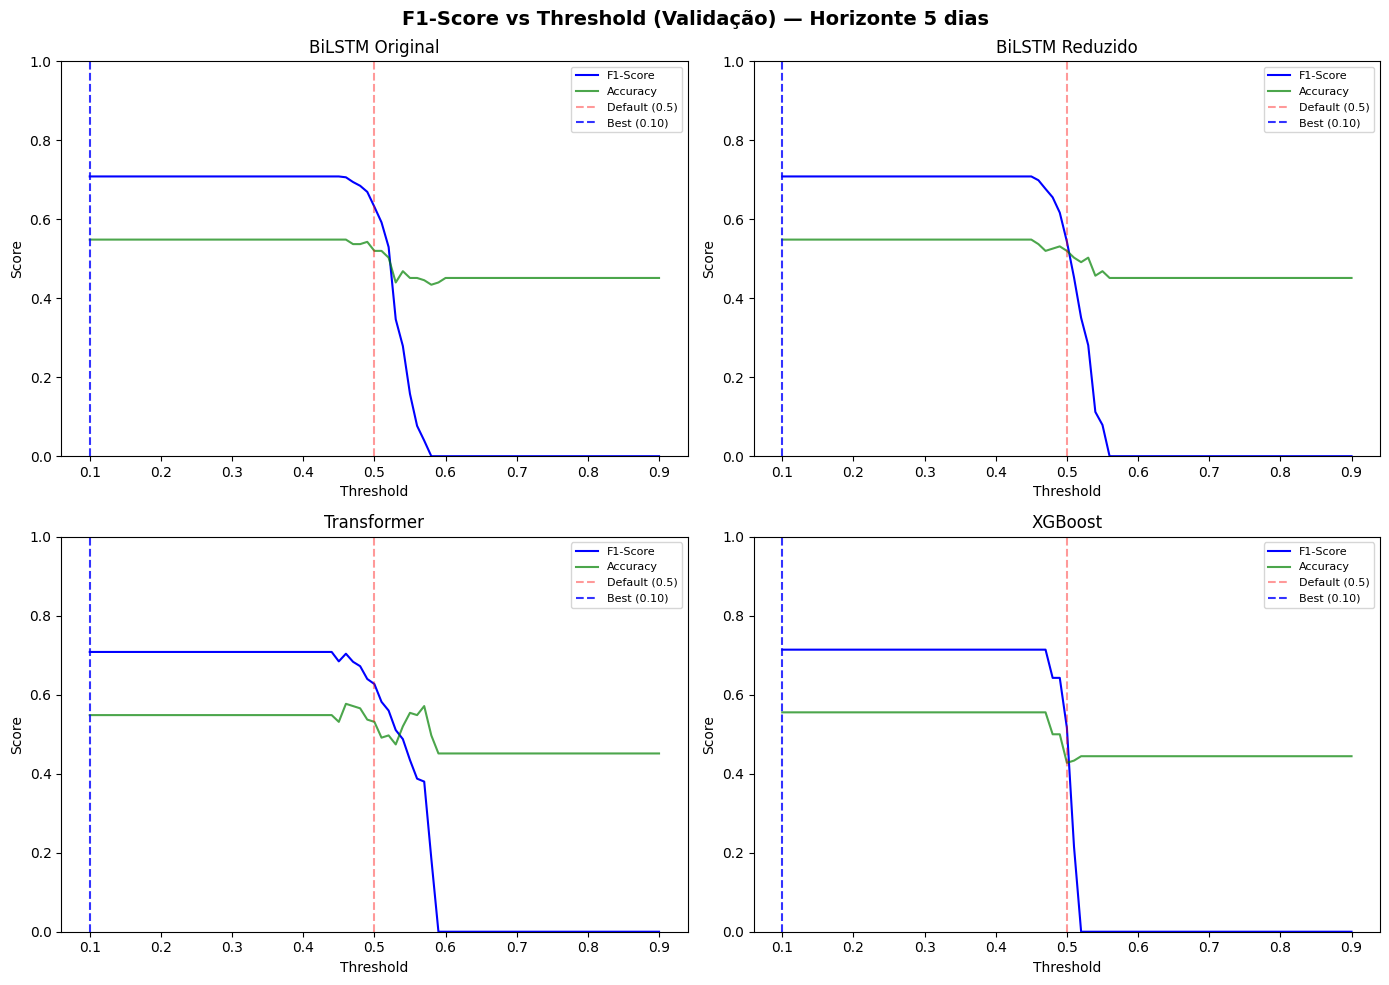


Thresholds ótimos (validação):
  BiLSTM Original: 0.10
  BiLSTM Reduzido: 0.10
  Transformer: 0.10
  XGBoost: 0.10


In [4]:
import torch
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score
import matplotlib.pyplot as plt

# Split indices
n = len(X_seq)
n_train = int(n * 0.7)
n_val = int(n * 0.15)
val_idx = slice(n_train, n_train + n_val)
test_idx = slice(n_train + n_val, n)

def get_probs(model, X_seq, idx):
    model.eval()
    X = torch.tensor(X_seq[idx], dtype=torch.float32).to(device)
    with torch.no_grad():
        return model(X).cpu().numpy()

y_val = y[val_idx]

# XGBoost val split
n_xgb = len(X_flat)
n_train_xgb = int(n_xgb * 0.7)
n_val_xgb = int(n_xgb * 0.15)
X_val_xgb = X_flat[n_train_xgb:n_train_xgb + n_val_xgb]
y_val_xgb = y_flat[n_train_xgb:n_train_xgb + n_val_xgb]

val_probs = {
    'BiLSTM Original': get_probs(model_orig, X_seq, val_idx),
    'BiLSTM Reduzido': get_probs(model_red, X_seq, val_idx),
    'Transformer': get_probs(tf_model, X_seq, val_idx),
    'XGBoost': xgb_model.predict_proba(X_val_xgb)[:, 1],
}

test_probs = {
    'BiLSTM Original': get_probs(model_orig, X_seq, test_idx),
    'BiLSTM Reduzido': get_probs(model_red, X_seq, test_idx),
    'Transformer': get_probs(tf_model, X_seq, test_idx),
    'XGBoost': xgb_model.predict_proba(X_test_xgb)[:, 1],
}
y_test_seq = y[test_idx]

# Threshold search
thresholds = np.arange(0.10, 0.91, 0.01)
best_thresholds = {}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('F1-Score vs Threshold (Validação) — Horizonte 5 dias', fontsize=14, fontweight='bold')

for ax, (name, probs) in zip(axes.flat, val_probs.items()):
    y_v = y_val_xgb if name == 'XGBoost' else y_val
    f1s = [f1_score(y_v, (probs > t).astype(int), zero_division=0) for t in thresholds]
    accs = [accuracy_score(y_v, (probs > t).astype(int)) for t in thresholds]
    
    best_t = thresholds[np.argmax(f1s)]
    best_thresholds[name] = best_t
    
    ax.plot(thresholds, f1s, label='F1-Score', color='blue')
    ax.plot(thresholds, accs, label='Accuracy', color='green', alpha=0.7)
    ax.axvline(0.5, color='red', linestyle='--', alpha=0.4, label='Default (0.5)')
    ax.axvline(best_t, color='blue', linestyle='--', alpha=0.8, label=f'Best ({best_t:.2f})')
    ax.set_title(name)
    ax.set_xlabel('Threshold')
    ax.set_ylabel('Score')
    ax.legend(fontsize=8)
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('threshold_search_h5.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nThresholds ótimos (validação):')
for name, t in best_thresholds.items():
    print(f'  {name}: {t:.2f}')

## 5. Avaliação no Teste — Default vs Otimizado

In [5]:
from sklearn.metrics import precision_score, recall_score

rows = []
for name, probs in test_probs.items():
    y_t = y_test_xgb if name == 'XGBoost' else y_test_seq
    t_opt = best_thresholds[name]
    auc = roc_auc_score(y_t, probs)
    
    for t, label in [(0.5, 'Default'), (t_opt, 'Otimizado')]:
        preds = (probs > t).astype(int)
        rows.append({
            'Modelo': name,
            'Threshold': f'{label} ({t:.2f})',
            'ROC-AUC': auc,
            'Accuracy': accuracy_score(y_t, preds),
            'F1 (Sobe)': f1_score(y_t, preds, zero_division=0),
            'Precision': precision_score(y_t, preds, zero_division=0),
            'Recall': recall_score(y_t, preds, zero_division=0),
        })

df_compare = pd.DataFrame(rows)
display(df_compare.style.format({
    'ROC-AUC': '{:.4f}', 'Accuracy': '{:.1%}',
    'F1 (Sobe)': '{:.4f}', 'Precision': '{:.4f}', 'Recall': '{:.4f}',
}).highlight_max(axis=0, subset=['Accuracy', 'F1 (Sobe)'], color='lightgreen'))

,Modelo,Threshold,ROC-AUC,Accuracy,F1 (Sobe),Precision,Recall
0,BiLSTM Original,Default (0.50),0.4329,59.9%,0.7491,0.5989,1.0000
1,BiLSTM Original,Otimizado (0.10),0.4329,59.9%,0.7491,0.5989,1.0000
2,BiLSTM Reduzido,Default (0.50),0.4596,56.5%,0.6857,0.6043,0.7925
3,BiLSTM Reduzido,Otimizado (0.10),0.4596,59.9%,0.7491,0.5989,1.0000
4,Transformer,Default (0.50),0.5878,40.1%,0.0000,0.0000,0.0000
5,Transformer,Otimizado (0.10),0.5878,59.9%,0.7491,0.5989,1.0000
6,XGBoost,Default (0.50),0.5278,55.8%,0.6581,0.6063,0.7196
7,XGBoost,Otimizado (0.10),0.5278,59.1%,0.7431,0.5912,1.0000


## 6. Matrizes de Confusão — Threshold Otimizado

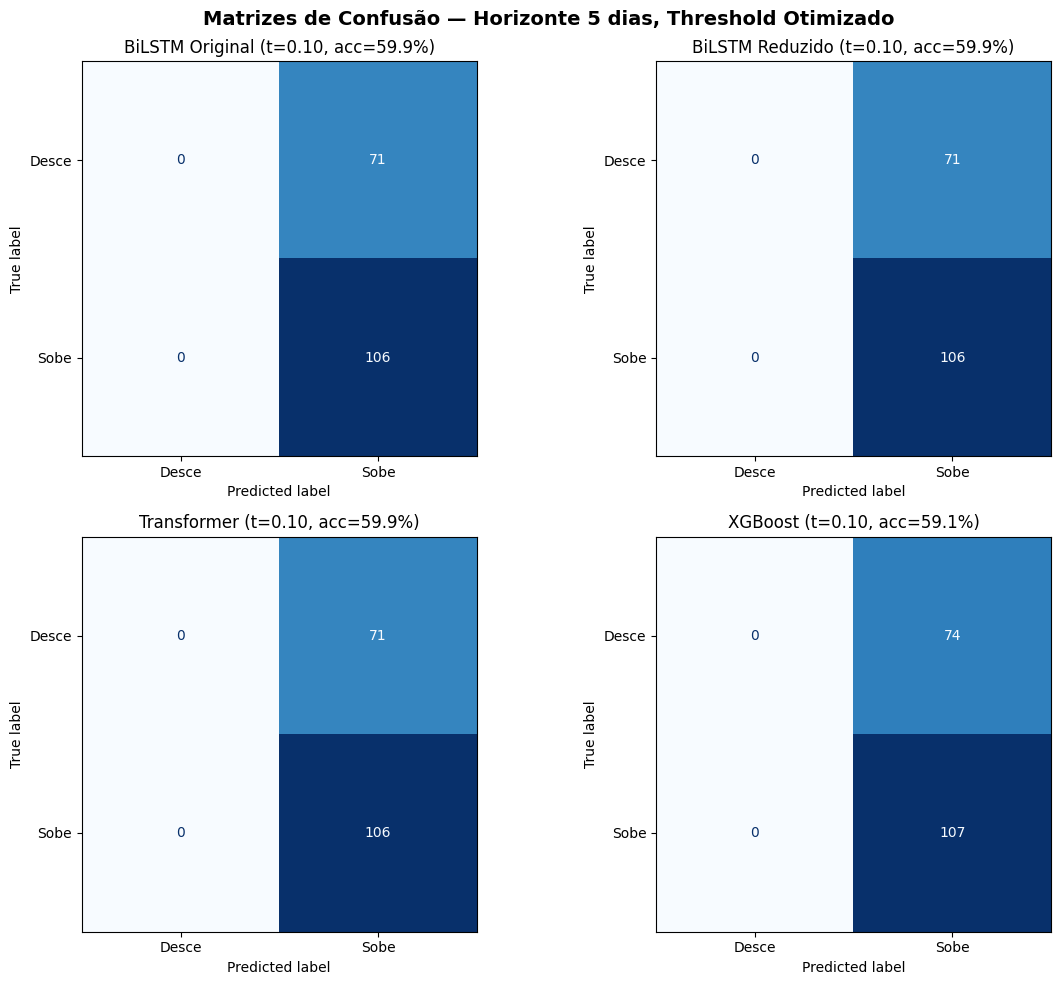

In [6]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Matrizes de Confusão — Horizonte 5 dias, Threshold Otimizado', fontsize=14, fontweight='bold')

for ax, (name, probs) in zip(axes.flat, test_probs.items()):
    y_t = y_test_xgb if name == 'XGBoost' else y_test_seq
    t_opt = best_thresholds[name]
    preds = (probs > t_opt).astype(int)
    cm = confusion_matrix(y_t, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Desce', 'Sobe'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    acc = accuracy_score(y_t, preds)
    ax.set_title(f'{name} (t={t_opt:.2f}, acc={acc:.1%})')

plt.tight_layout()
plt.savefig('confusion_h5.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Curvas ROC Comparativas

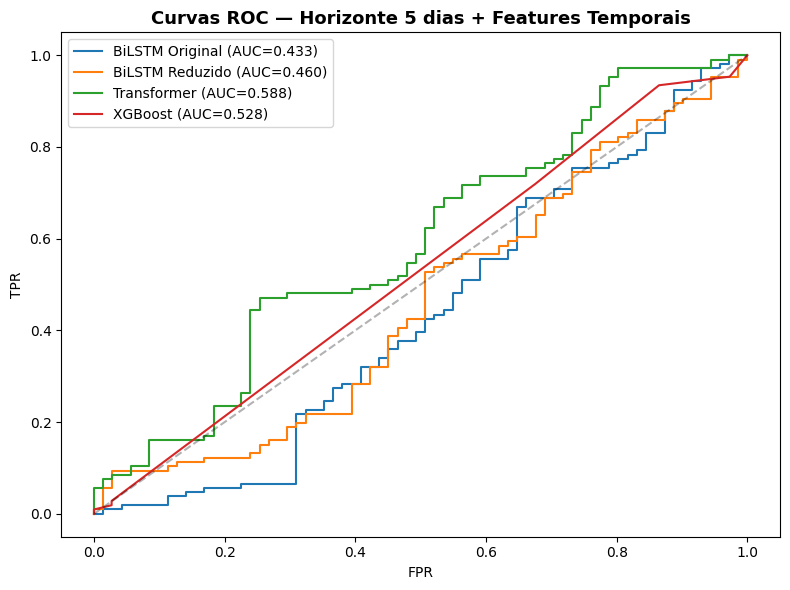

In [7]:
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for (name, probs), color in zip(test_probs.items(), colors):
    y_t = y_test_xgb if name == 'XGBoost' else y_test_seq
    fpr, tpr, _ = roc_curve(y_t, probs)
    auc = roc_auc_score(y_t, probs)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_title('Curvas ROC — Horizonte 5 dias + Features Temporais', fontsize=13, fontweight='bold')
ax.set_xlabel('FPR')
ax.set_ylabel('TPR')
ax.legend()
plt.tight_layout()
plt.savefig('roc_h5.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Importância de Features (XGBoost)

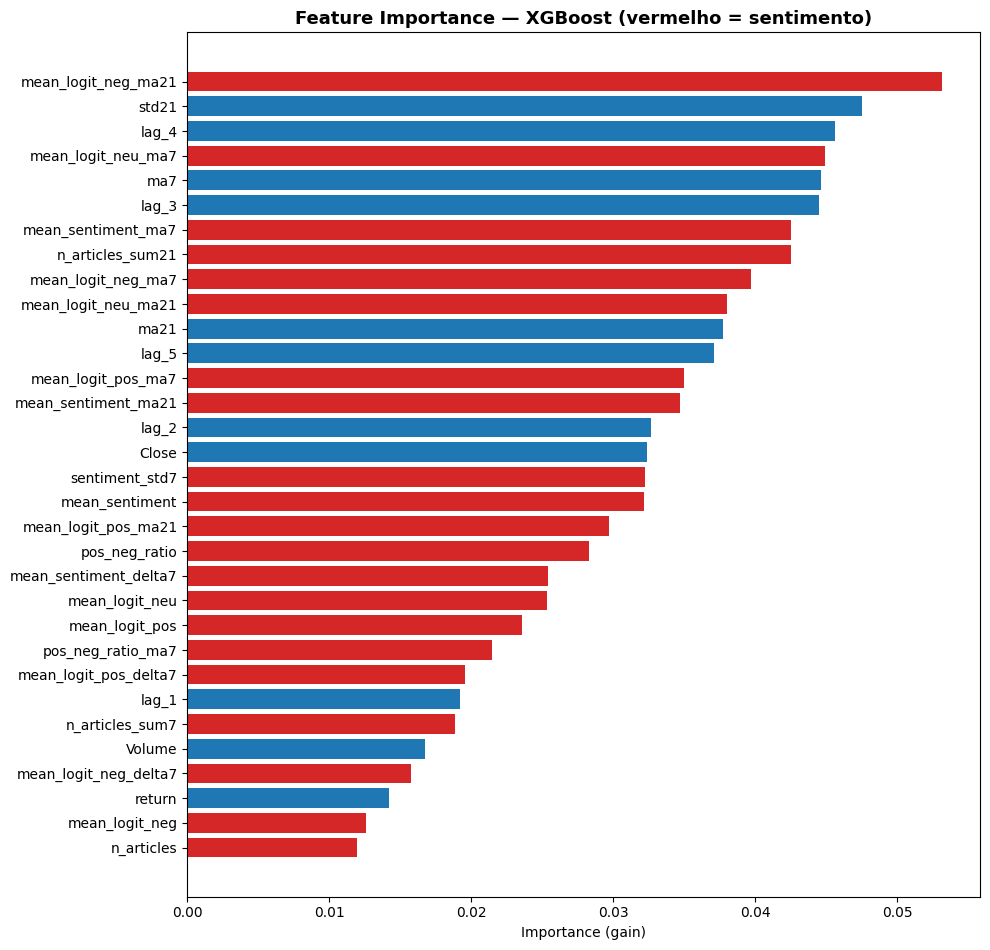


Top 10 features:
  0.0380  mean_logit_neu_ma21 [SENT]
  0.0397  mean_logit_neg_ma7 [SENT]
  0.0425  n_articles_sum21 [SENT]
  0.0426  mean_sentiment_ma7 [SENT]
  0.0445  lag_3
  0.0447  ma7
  0.0449  mean_logit_neu_ma7 [SENT]
  0.0456  lag_4
  0.0476  std21
  0.0532  mean_logit_neg_ma21 [SENT]


In [8]:
# Feature importance do XGBoost para entender quais features contribuem
importances = xgb_model.feature_importances_
feat_imp = pd.DataFrame({
    'feature': features_flat,
    'importance': importances
}).sort_values('importance', ascending=True)

# Highlight sentiment-derived features
sent_derived = [f for f in features_flat if any(k in f for k in ['logit', 'sentiment', 'n_articles', 'pos_neg', 'ratio'])]
colors = ['#d62728' if f in sent_derived else '#1f77b4' for f in feat_imp['feature']]

fig, ax = plt.subplots(figsize=(10, max(8, len(features_flat) * 0.3)))
ax.barh(feat_imp['feature'], feat_imp['importance'], color=colors)
ax.set_xlabel('Importance (gain)')
ax.set_title('Feature Importance — XGBoost (vermelho = sentimento)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance_h5.png', dpi=150, bbox_inches='tight')
plt.show()

# Top 10
print('\nTop 10 features:')
for _, row in feat_imp.tail(10).iterrows():
    tag = ' [SENT]' if row['feature'] in sent_derived else ''
    print(f"  {row['importance']:.4f}  {row['feature']}{tag}")

## 9. Resumo Final

In [9]:
print('RESUMO — Horizonte 5 dias + Features Temporais de Sentimento')
print('=' * 70)

for name, probs in test_probs.items():
    y_t = y_test_xgb if name == 'XGBoost' else y_test_seq
    t_opt = best_thresholds[name]
    preds_opt = (probs > t_opt).astype(int)
    preds_def = (probs > 0.5).astype(int)
    
    auc = roc_auc_score(y_t, probs)
    acc_opt = accuracy_score(y_t, preds_opt)
    f1_opt = f1_score(y_t, preds_opt, zero_division=0)
    acc_def = accuracy_score(y_t, preds_def)
    
    # Check if predictions use both classes
    n_classes = len(set(preds_opt))
    discrimina = 'Sim' if n_classes > 1 else 'Não (classe única)'
    
    print(f'\n{name}')
    print(f'  Threshold:   {t_opt:.2f}')
    print(f'  ROC-AUC:     {auc:.4f}')
    print(f'  Accuracy:    {acc_def:.1%} (t=0.5) -> {acc_opt:.1%} (t={t_opt:.2f})')
    print(f'  F1 (Sobe):   {f1_opt:.4f}')
    print(f'  Discrimina:  {discrimina}')

RESUMO — Horizonte 5 dias + Features Temporais de Sentimento

BiLSTM Original
  Threshold:   0.10
  ROC-AUC:     0.4329
  Accuracy:    59.9% (t=0.5) -> 59.9% (t=0.10)
  F1 (Sobe):   0.7491
  Discrimina:  Não (classe única)

BiLSTM Reduzido
  Threshold:   0.10
  ROC-AUC:     0.4596
  Accuracy:    56.5% (t=0.5) -> 59.9% (t=0.10)
  F1 (Sobe):   0.7491
  Discrimina:  Não (classe única)

Transformer
  Threshold:   0.10
  ROC-AUC:     0.5878
  Accuracy:    40.1% (t=0.5) -> 59.9% (t=0.10)
  F1 (Sobe):   0.7491
  Discrimina:  Não (classe única)

XGBoost
  Threshold:   0.10
  ROC-AUC:     0.5278
  Accuracy:    55.8% (t=0.5) -> 59.1% (t=0.10)
  F1 (Sobe):   0.7431
  Discrimina:  Não (classe única)
